In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [18]:
df = pd.read_csv('StudentsPerformance.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(1000, 8)
   gender race/ethnicity  ... reading score writing score
0  female        group B  ...            72            74
1  female        group C  ...            90            88
2  female        group B  ...            95            93
3    male        group A  ...            57            44
4    male        group C  ...            78            75

[5 rows x 8 columns]
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


Define the target

In [19]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

target = 'average_score'

In [20]:
x = df.drop(columns = ["math score", "reading score", "writing score", "average_score"])
y = df[target]

Encoding Categoricals


In [21]:
print(x.dtypes)

gender                         str
race/ethnicity                 str
parental level of education    str
lunch                          str
test preparation course        str
dtype: object


In [22]:
num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

/var/folders/zz/0nnm235s71z7_t9plwkr7f6r0000gn/T/ipykernel_33167/2820141357.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include="object").columns


In [23]:
x = preprocessor.fit_transform(x)

x.shape

(1000, 17)

Train/Test Split

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print(f"Training Samples: {x_train.shape}")
print(f"Test Samples: {x_test.shape}")

Training Samples: (800, 17)
Test Samples: (200, 17)


In [25]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [27]:
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) 

    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 12.1957
- Mean Absolute Error: 9.9361
- R2 Score: 0.2543
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 13.4016
- Mean Absolute Error: 10.4902
- R2 Score: 0.1622


Lasso
Model performance for Training set
- Root Mean Squared Error: 13.1964
- Mean Absolute Error: 10.5625
- R2 Score: 0.1269
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 14.1338
- Mean Absolute Error: 11.0886
- R2 Score: 0.0681


Ridge
Model performance for Training set
- Root Mean Squared Error: 12.1957
- Mean Absolute Error: 9.9355
- R2 Score: 0.2543
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 13.4034
- Mean Absolute Error: 10.4929
- R2 Score: 0.1619


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 11.7007
- Mean Absolute Error: 9.5431
- R2 Score: 0.3136
------------

In [28]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.162172
2,Ridge,0.161946
7,AdaBoost Regressor,0.105783
1,Lasso,0.068120
5,Random Forest Regressor,-0.019185
3,K-Neighbors Regressor,-0.047842
6,XGBRegressor,-0.070459
4,Decision Tree,-0.079119


In [29]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 16.22


<Axes: xlabel='average_score', ylabel='Predicted'>

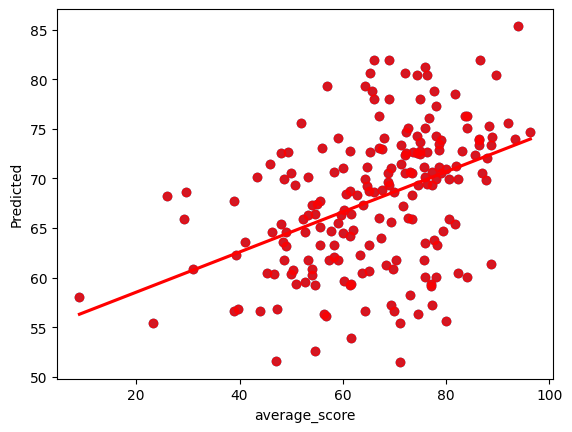

In [30]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red')

In [31]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,87.000000,70.522771,16.477229
737,64.000000,67.280953,-3.280953
740,75.000000,72.795938,2.204062
660,74.666667,56.369164,18.297503
411,81.666667,78.496796,3.169871
...,...,...,...
408,55.000000,67.398758,-12.398758
332,57.000000,79.350894,-22.350894
208,77.000000,59.403257,17.596743
613,72.000000,70.522771,1.477229


# Interpretation: 
Through the modeling, the Linear Regression seems to be the fittest of all the model as it has the highest R^2. However, it is still not the best model for this dataset as all of other models are all performing poorly. In adition, it is also due to the nonlinear realtionship between the average_score and other variables. Therefore, it is not capturing properly. Lastly, the reasons why the XGBRegressor or Decision is underperformance is due the small data.